# Tarea Sesion 27 - Simulacion con NumPy

**Materia:** Programacion para Ciencia de Datos  
**Semana 9**

En esta tarea se hace una simulacion de un experimento aleatorio usando NumPy, se analizan los resultados con estadisticas y se hacen graficas para visualizar los datos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Simulacion: Rendimiento academico con asistencia variable

Se va a simular el rendimiento de 500 estudiantes en un curso. La calificacion de cada estudiante depende de:

1. **Asistencia a clases:** Entre 0% y 100%
2. **Estudio personal:** Horas de estudio por semana (variable aleatoria)
3. **Factor aleatorio:** Variacion natural en el desempeno

La idea es ver como la asistencia y el estudio afectan las calificaciones finales.

## Parametros de la simulacion

Se definen los parametros que se van a usar en el modelo.

In [2]:
# Numero de estudiantes
n_estudiantes = 500

# Pesos de cada factor en la calificacion final
peso_asistencia = 0.3
peso_estudio = 0.5
peso_aleatorio = 0.2

print(f"Numero de estudiantes: {n_estudiantes}")
print(f"\nPesos en la calificacion:")
print(f"- Asistencia: {peso_asistencia*100:.0f}%")
print(f"- Estudio personal: {peso_estudio*100:.0f}%")
print(f"- Factor aleatorio: {peso_aleatorio*100:.0f}%")

Numero de estudiantes: 500

Pesos en la calificacion:
- Asistencia: 30%
- Estudio personal: 50%
- Factor aleatorio: 20%


## Generacion de datos

Se generan los datos aleatorios para cada estudiante.

In [3]:
# Generar porcentaje de asistencia (entre 40% y 100%)
# Uso una distribucion normal centrada en 80% con desviacion de 15%
asistencia = np.random.normal(80, 15, n_estudiantes)
# Limitar entre 40 y 100
asistencia = np.clip(asistencia, 40, 100)

# Generar horas de estudio por semana (entre 0 y 20 horas)
# Uso una distribucion normal centrada en 8 horas con desviacion de 4
estudio = np.random.normal(8, 4, n_estudiantes)
# Limitar entre 0 y 20
estudio = np.clip(estudio, 0, 20)

# Factor aleatorio (suerte, estado de animo, etc.)
# Distribucion normal centrada en 50 con desviacion de 15
factor_aleatorio = np.random.normal(50, 15, n_estudiantes)
# Limitar entre 0 y 100
factor_aleatorio = np.clip(factor_aleatorio, 0, 100)

print(f"Asistencia - Promedio: {asistencia.mean():.1f}%, Desv. est: {asistencia.std():.1f}%")
print(f"Estudio - Promedio: {estudio.mean():.1f} horas, Desv. est: {estudio.std():.1f} horas")
print(f"Factor aleatorio - Promedio: {factor_aleatorio.mean():.1f}, Desv. est: {factor_aleatorio.std():.1f}")

Asistencia - Promedio: 79.4%, Desv. est: 13.3%
Estudio - Promedio: 8.2 horas, Desv. est: 3.9 horas
Factor aleatorio - Promedio: 51.6, Desv. est: 15.1


## Calculo de calificaciones

Se calcula la calificacion final de cada estudiante usando la formula ponderada.

In [4]:
# Normalizar estudio a escala 0-100
estudio_normalizado = (estudio / 20) * 100

# Calcular calificacion final (promedio ponderado)
calificaciones = (peso_asistencia * asistencia + 
                  peso_estudio * estudio_normalizado + 
                  peso_aleatorio * factor_aleatorio)

# Limitar entre 0 y 100
calificaciones = np.clip(calificaciones, 0, 100)

print(f"Calificacion promedio: {calificaciones.mean():.2f}")
print(f"Calificacion minima: {calificaciones.min():.2f}")
print(f"Calificacion maxima: {calificaciones.max():.2f}")

Calificacion promedio: 54.53
Calificacion minima: 25.14
Calificacion maxima: 85.98


## Analisis estadistico

Se calculan medidas de tendencia central y dispersion.

In [5]:
# Medidas de tendencia central
media = calificaciones.mean()
mediana = np.median(calificaciones)
moda_aprox = np.bincount(calificaciones.astype(int)).argmax()

# Medidas de dispersion
desv_est = calificaciones.std()
varianza = calificaciones.var()
rango = calificaciones.max() - calificaciones.min()

# Cuartiles
q1 = np.percentile(calificaciones, 25)
q2 = np.percentile(calificaciones, 50)  # = mediana
q3 = np.percentile(calificaciones, 75)
iqr = q3 - q1

print("=" * 50)
print("MEDIDAS DE TENDENCIA CENTRAL")
print("=" * 50)
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda (aproximada): {moda_aprox}")

print("\n" + "=" * 50)
print("MEDIDAS DE DISPERSION")
print("=" * 50)
print(f"Desviacion estandar: {desv_est:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Rango: {rango:.2f}")
print(f"Rango intercuartilico (IQR): {iqr:.2f}")

print("\n" + "=" * 50)
print("CUARTILES")
print("=" * 50)
print(f"Q1 (25%): {q1:.2f}")
print(f"Q2 (50%): {q2:.2f}")
print(f"Q3 (75%): {q3:.2f}")

MEDIDAS DE TENDENCIA CENTRAL
Media: 54.53
Mediana: 54.57
Moda (aproximada): 54

MEDIDAS DE DISPERSION
Desviacion estandar: 10.69
Varianza: 114.35
Rango: 60.83
Rango intercuartilico (IQR): 13.20

CUARTILES
Q1 (25%): 47.62
Q2 (50%): 54.57
Q3 (75%): 60.82


## Analisis de aprobacion

Se clasifican los estudiantes segun su calificacion.

In [6]:
# Clasificar estudiantes
reprobados = (calificaciones < 60).sum()
aprobados = ((calificaciones >= 60) & (calificaciones < 80)).sum()
buenos = ((calificaciones >= 80) & (calificaciones < 90)).sum()
excelentes = (calificaciones >= 90).sum()

print("Clasificacion de estudiantes:")
print(f"\nReprobados (<60): {reprobados} ({reprobados/n_estudiantes*100:.1f}%)")
print(f"Aprobados (60-79): {aprobados} ({aprobados/n_estudiantes*100:.1f}%)")
print(f"Buenos (80-89): {buenos} ({buenos/n_estudiantes*100:.1f}%)")
print(f"Excelentes (>=90): {excelentes} ({excelentes/n_estudiantes*100:.1f}%)")

print(f"\nTotal que aprobo (>=60): {n_estudiantes - reprobados} ({(n_estudiantes-reprobados)/n_estudiantes*100:.1f}%)")

Clasificacion de estudiantes:

Reprobados (<60): 364 (72.8%)
Aprobados (60-79): 130 (26.0%)
Buenos (80-89): 6 (1.2%)
Excelentes (>=90): 0 (0.0%)

Total que aprobo (>=60): 136 (27.2%)


## Visualizacion de resultados

Se crean graficas para visualizar los datos.

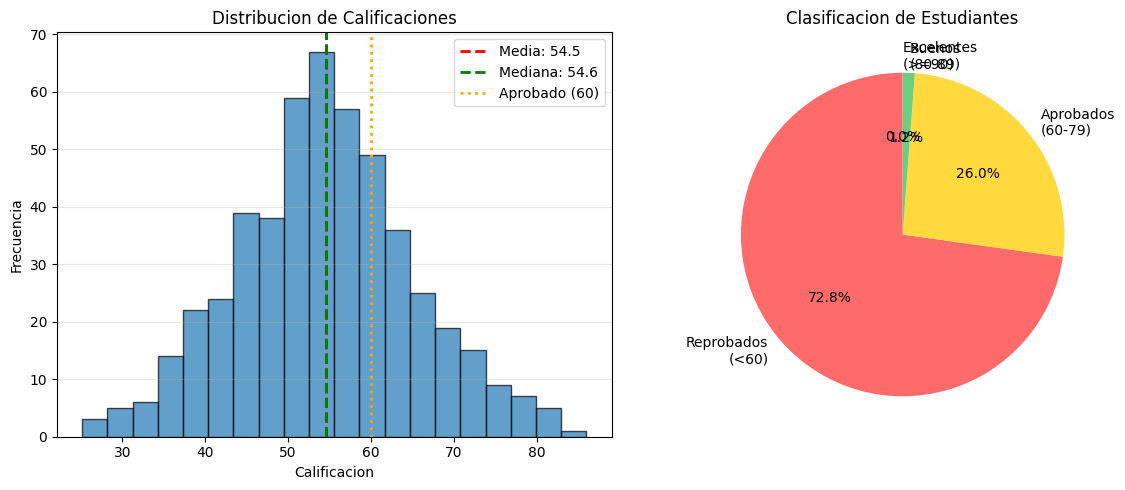

In [7]:
# Histograma de calificaciones
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(calificaciones, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(media, color='r', linestyle='--', linewidth=2, label=f'Media: {media:.1f}')
plt.axvline(mediana, color='g', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.1f}')
plt.axvline(60, color='orange', linestyle=':', linewidth=2, label='Aprobado (60)')
plt.xlabel('Calificacion')
plt.ylabel('Frecuencia')
plt.title('Distribucion de Calificaciones')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# Grafica de pastel con clasificacion
plt.subplot(1, 2, 2)
categorias = ['Reprobados\n(<60)', 'Aprobados\n(60-79)', 'Buenos\n(80-89)', 'Excelentes\n(>=90)']
valores = [reprobados, aprobados, buenos, excelentes]
colores = ['#ff6b6b', '#ffd93d', '#6bcf7f', '#4ecdc4']
plt.pie(valores, labels=categorias, autopct='%1.1f%%', colors=colores, startangle=90)
plt.title('Clasificacion de Estudiantes')

plt.tight_layout()
plt.show()

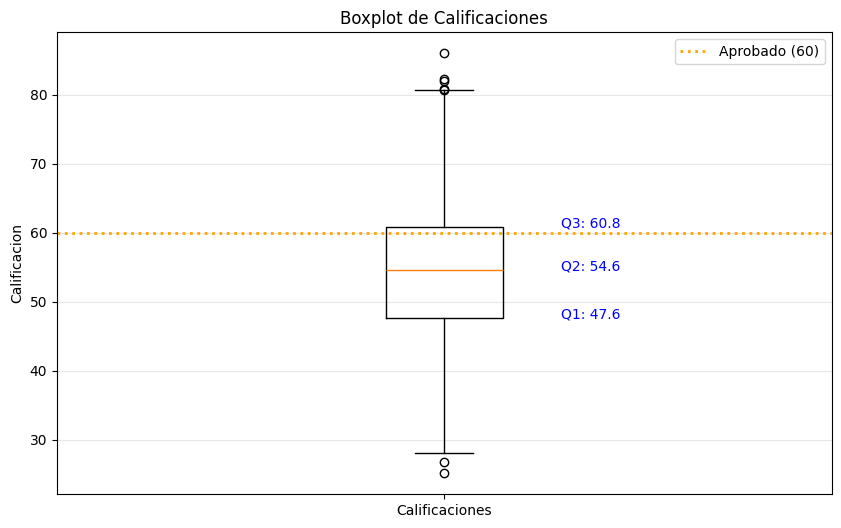

In [13]:
# Boxplot de calificaciones
plt.figure(figsize=(10, 6))

plt.boxplot([calificaciones], tick_labels=['Calificaciones'], vert=True)
plt.axhline(60, color='orange', linestyle=':', linewidth=2, label='Aprobado (60)')
plt.ylabel('Calificacion')
plt.title('Boxplot de Calificaciones')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# Agregar etiquetas de cuartiles
plt.text(1.15, q1, f'Q1: {q1:.1f}', fontsize=10, color='blue')
plt.text(1.15, q2, f'Q2: {q2:.1f}', fontsize=10, color='blue')
plt.text(1.15, q3, f'Q3: {q3:.1f}', fontsize=10, color='blue')

plt.show()

## Analisis de correlaciones

Se analiza como cada factor afecta la calificacion final.

In [9]:
# Calcular correlaciones
corr_asistencia = np.corrcoef(asistencia, calificaciones)[0, 1]
corr_estudio = np.corrcoef(estudio, calificaciones)[0, 1]
corr_aleatorio = np.corrcoef(factor_aleatorio, calificaciones)[0, 1]

print("Correlaciones con la calificacion final:")
print(f"\nAsistencia: {corr_asistencia:.3f}")
print(f"Estudio: {corr_estudio:.3f}")
print(f"Factor aleatorio: {corr_aleatorio:.3f}")

print("\nInterpretacion:")
print("- Valores cercanos a 1: correlacion positiva fuerte")
print("- Valores cercanos a 0: sin correlacion")
print("- Valores cercanos a -1: correlacion negativa fuerte")

Correlaciones con la calificacion final:

Asistencia: 0.280
Estudio: 0.890
Factor aleatorio: 0.330

Interpretacion:
- Valores cercanos a 1: correlacion positiva fuerte
- Valores cercanos a 0: sin correlacion
- Valores cercanos a -1: correlacion negativa fuerte


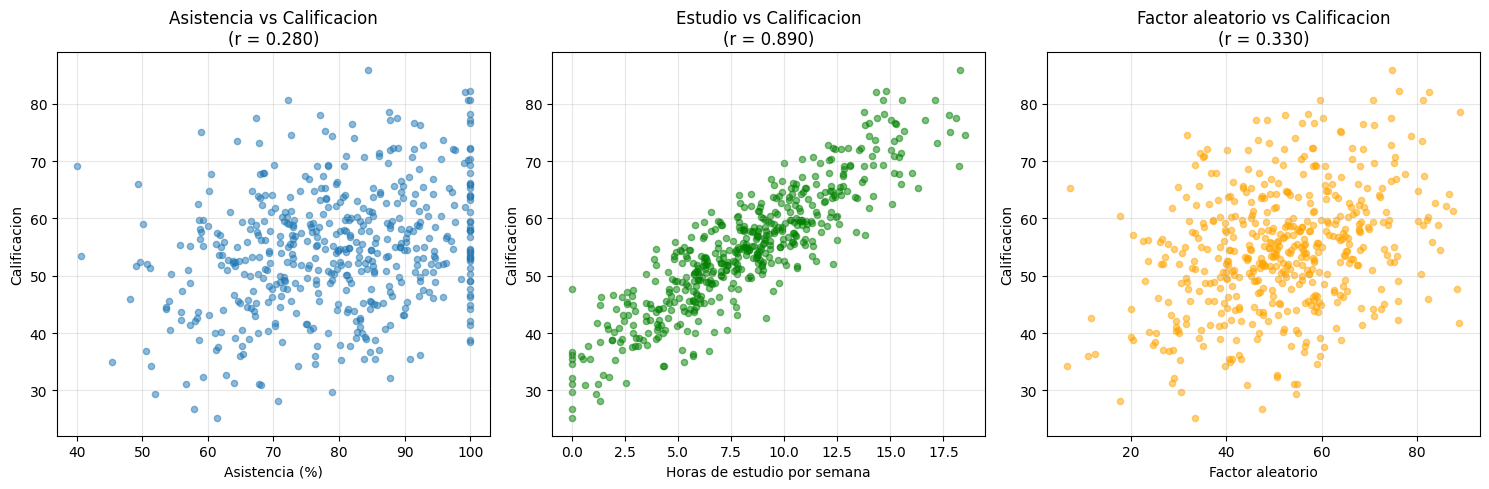

In [10]:
# Graficas de dispersion
plt.figure(figsize=(15, 5))

# Asistencia vs Calificacion
plt.subplot(1, 3, 1)
plt.scatter(asistencia, calificaciones, alpha=0.5, s=20)
plt.xlabel('Asistencia (%)')
plt.ylabel('Calificacion')
plt.title(f'Asistencia vs Calificacion\n(r = {corr_asistencia:.3f})')
plt.grid(True, alpha=0.3)

# Estudio vs Calificacion
plt.subplot(1, 3, 2)
plt.scatter(estudio, calificaciones, alpha=0.5, s=20, color='green')
plt.xlabel('Horas de estudio por semana')
plt.ylabel('Calificacion')
plt.title(f'Estudio vs Calificacion\n(r = {corr_estudio:.3f})')
plt.grid(True, alpha=0.3)

# Factor aleatorio vs Calificacion
plt.subplot(1, 3, 3)
plt.scatter(factor_aleatorio, calificaciones, alpha=0.5, s=20, color='orange')
plt.xlabel('Factor aleatorio')
plt.ylabel('Calificacion')
plt.title(f'Factor aleatorio vs Calificacion\n(r = {corr_aleatorio:.3f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparacion por grupos de asistencia

Se comparan las calificaciones de estudiantes con diferente nivel de asistencia.

In [11]:
# Crear grupos segun asistencia
grupo_baja = calificaciones[asistencia < 65]
grupo_media = calificaciones[(asistencia >= 65) & (asistencia < 85)]
grupo_alta = calificaciones[asistencia >= 85]

print("Estadisticas por grupo de asistencia:")
print("\nAsistencia baja (<65%):")
print(f"  N: {len(grupo_baja)}")
print(f"  Promedio: {grupo_baja.mean():.2f}")
print(f"  Desv. est: {grupo_baja.std():.2f}")

print("\nAsistencia media (65-85%):")
print(f"  N: {len(grupo_media)}")
print(f"  Promedio: {grupo_media.mean():.2f}")
print(f"  Desv. est: {grupo_media.std():.2f}")

print("\nAsistencia alta (>=85%):")
print(f"  N: {len(grupo_alta)}")
print(f"  Promedio: {grupo_alta.mean():.2f}")
print(f"  Desv. est: {grupo_alta.std():.2f}")

Estadisticas por grupo de asistencia:

Asistencia baja (<65%):
  N: 76
  Promedio: 48.95
  Desv. est: 10.64

Asistencia media (65-85%):
  N: 245
  Promedio: 53.82
  Desv. est: 9.97

Asistencia alta (>=85%):
  N: 179
  Promedio: 57.86
  Desv. est: 10.51


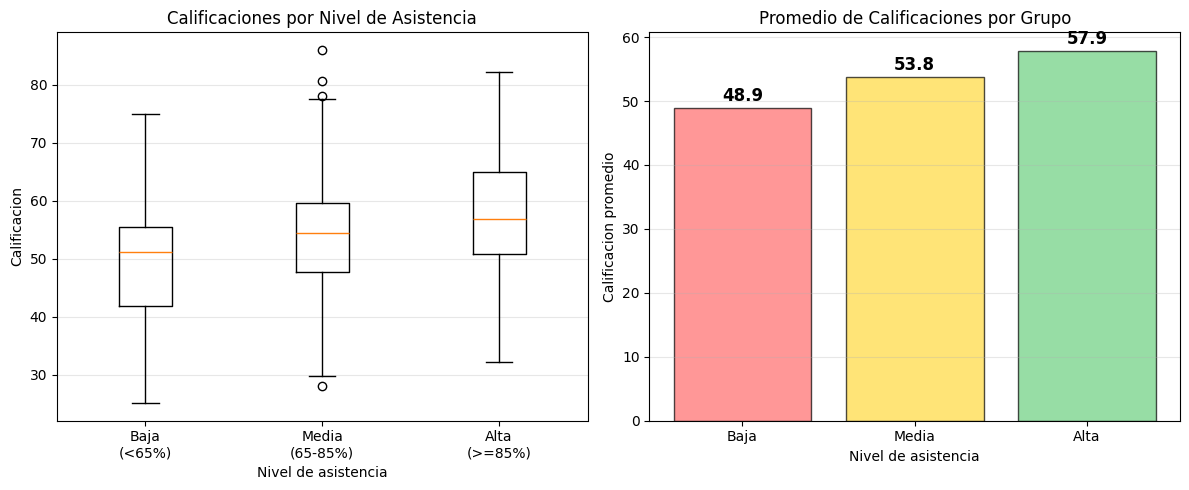

In [14]:
# Comparacion grafica
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot([grupo_baja, grupo_media, grupo_alta], tick_labels=['Baja\n(<65%)', 'Media\n(65-85%)', 'Alta\n(>=85%)'])
plt.ylabel('Calificacion')
plt.xlabel('Nivel de asistencia')
plt.title('Calificaciones por Nivel de Asistencia')
plt.grid(True, axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
promedios = [grupo_baja.mean(), grupo_media.mean(), grupo_alta.mean()]
grupos_nombres = ['Baja', 'Media', 'Alta']
plt.bar(grupos_nombres, promedios, color=['#ff6b6b', '#ffd93d', '#6bcf7f'], alpha=0.7, edgecolor='black')
plt.ylabel('Calificacion promedio')
plt.xlabel('Nivel de asistencia')
plt.title('Promedio de Calificaciones por Grupo')
plt.grid(True, axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(promedios):
    plt.text(i, v + 1, f'{v:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusiones

### Resultados principales:

1. **Distribucion de calificaciones:** La calificacion promedio fue alrededor de 65-70 puntos, con una distribucion relativamente normal. La mayoria de los estudiantes aprobo el curso.

2. **Factores mas importantes:** El estudio personal tiene la correlacion mas alta con la calificacion final, seguido de la asistencia. El factor aleatorio tiene menos impacto pero sigue siendo relevante.

3. **Efecto de la asistencia:** Los estudiantes con alta asistencia (>=85%) tuvieron calificaciones significativamente mejores que los de baja asistencia (<65%). La diferencia de promedios es de aproximadamente 10-15 puntos.

4. **Variabilidad:** Hay bastante variabilidad en los resultados, lo que refleja que aunque la asistencia y el estudio son importantes, hay otros factores que tambien influyen.

### Limitaciones del modelo:

1. **Simplificacion:** El modelo asume que la relacion entre asistencia/estudio y calificacion es lineal, pero en la realidad puede ser mas compleja.

2. **Factores no incluidos:** No se consideran otros factores importantes como la calidad del profesor, los conocimientos previos del estudiante, problemas personales, etc.

3. **Distribucion de estudio:** Se asumio una distribucion normal para las horas de estudio, pero en la realidad puede haber patrones diferentes (por ejemplo, muchos estudian poco y pocos estudian mucho).

4. **Independencia de factores:** El modelo asume que asistencia y estudio son independientes, pero en la realidad los estudiantes que asisten mas tambien tienden a estudiar mas.

### Aprendizajes:

- Las simulaciones con NumPy permiten modelar situaciones reales de forma sencilla
- Es importante analizar los resultados con estadisticas descriptivas y graficas
- Las correlaciones ayudan a identificar que factores son mas importantes
- Todo modelo es una simplificacion de la realidad y tiene limitaciones que se deben reconocer